In [5]:
import paarti.utils.maos_utils as mu
import paarti.utils.koa_utils as ku
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
from pathlib import Path
from astropy.io import fits

from astropy.table import Table
from pykoa.koa import Koa

In [16]:
param = dict()
param['instrument'] = 'nirc2'
param['date'] = '2010-08-15/2017-08-24'
param['target'] = 'ao_confirmation'

Koa.query_criteria(param, './parameters.tbl', overwrite=True, format='ipac')
rec = Table.read('./parameters.tbl', format='ipac')
print(rec[::100])

submitting request...
Result downloaded to file [./parameters.tbl]
        koaid          instrume    targname    ...  slitmm slitname slsname
                                               ...    mm                   
---------------------- -------- -------------- ... ------- -------- -------
N2.20100817.05227.fits    NIRC2             -- ...     0.0     none   clear
N2.20101013.07735.fits    NIRC2             -- ...     0.0     none Unknown
N2.20110126.15226.fits    NIRC2        unknown ...     0.0     none   clear
N2.20110211.27087.fits    NIRC2 s-COSMOS-08501 ...     0.0     none   clear
N2.20110211.27834.fits    NIRC2 s-COSMOS-08501 ...     0.0     none   clear
N2.20110211.67795.fits    NIRC2        NIRSPEC ...     0.0     none   clear
N2.20110211.71244.fits    NIRC2        NIRSPEC ...     0.0     none   clear
N2.20110211.71907.fits    NIRC2        NIRSPEC ...     0.0     none   clear
N2.20110211.72266.fits    NIRC2        NIRSPEC ...     0.0     none   clear
N2.20110211.72619.fit

In [3]:
ku.fetch_koa(date='2019-06-29', koa_dir=Path('/Users/bdigia/myg3/data/'), download=False, verbose=True)

submitting request...
Failed to connect to cx_Oracle
        koaid          instrume   targname   object koaimtyp frameno     ra      dec     date_obs       ut     elaptime waveblue wavered progid proginst  progpi                                                  progtitl                                                sig2nois  slitwidt                         filehand                         semid    propint camname coadds detmode dispers        filter       grsname  itime  multisam naxis1 naxis2 sampmode slitmm slitname slsname
                                                                                                               seconds  Microns  Microns                                                                                                                                           arcseconds                                                                   months                                                            seconds                                   mm   

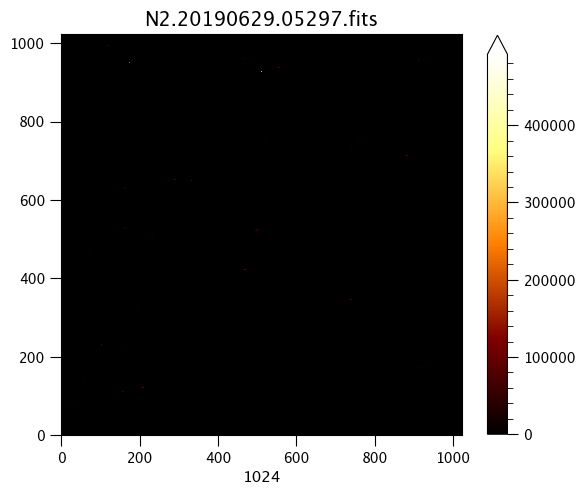

 id     xcentroid      ...        flux              mag        
--- ------------------ ... ----------------- ------------------
  1 497.48225008029124 ... 14.96543349188042 -2.937723253058293
 id      xcenter            ycenter         aperture_sum  
           pix                pix                         
--- ------------------ ----------------- -----------------
  1 497.48225008029124 521.3684832147277 2930434.283844778

Average pixel value in sky-subtracted KOA: 9.930803762516128
Maximum pixel value in sky-subtracted KOA: 491798.67448280915


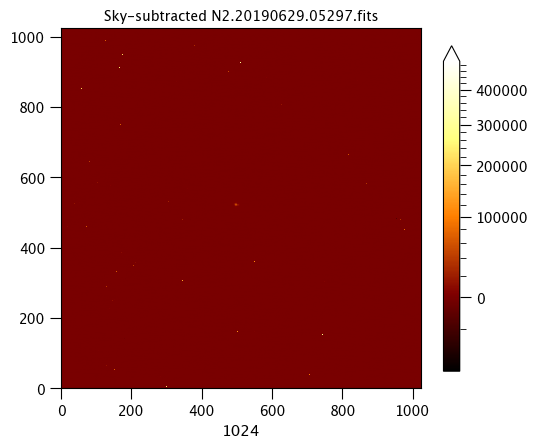

Keck II, ao_confirmation, = '                  ' / Comment

KOA DQA generated keywords follow...



In [4]:
koa_files = [Path("/Users/bdigia/myg3/datadnload_dir_nirc2_calib0_2019-06-29/lev0/N2.20190629.05297.fits")]
            #  Path("/Users/bdigia/myg3/datadnload_dir_nirc2_calib0_2019-06-29/lev0/N2.20190629.10933.fits"), 
            #  Path("/Users/bdigia/myg3/datadnload_dir_nirc2_calib0_2019-06-29/lev0/N2.20190629.10957.fits"),
            #  Path("/Users/bdigia/myg3/datadnload_dir_nirc2_calib0_2019-06-29/lev0/N2.20190629.10983.fits"),
            #  Path("/Users/bdigia/myg3/datadnload_dir_nirc2_calib0_2019-06-29/lev0/N2.20190629.11007.fits"),
            #  Path("/Users/bdigia/myg3/datadnload_dir_nirc2_calib0_2019-06-29/lev0/N2.20190629.11033.fits"),
            #  Path("/Users/bdigia/myg3/datadnload_dir_nirc2_calib0_2019-06-29/lev0/N2.20190629.11058.fits"),
            #  Path("/Users/bdigia/myg3/datadnload_dir_nirc2_calib0_2019-06-29/lev0/N2.20190629.11083.fits"),
            #  Path("/Users/bdigia/myg3/datadnload_dir_nirc2_calib0_2019-06-29/lev0/N2.20190629.11109.fits"),
            #  Path("/Users/bdigia/myg3/datadnload_dir_nirc2_calib0_2019-06-29/lev0/N2.20190629.11134.fits")]

for file in koa_files:
    old_hdr, clean_img = ku.clean_koa(file)
    print(f"{old_hdr['TELESCOP']}, {old_hdr['OBJECT']}, {old_hdr['COMMENT']}") 


In [5]:
# Compute metrics on cleaned KOA image 
# re-defining koa_file as string because calc_strehl_on_sky does not
# iterate over Path object correctly in parsing
koa_files = ["/Users/bdigia/myg3/datadnload_dir_nirc2_calib0_2019-06-29/lev0/N2.20190629.05349.fits",
            #  "/Users/bdigia/myg3/datadnload_dir_nirc2_calib0_2019-06-29/lev0/N2.20190629.10463.fits",
             "/Users/bdigia/myg3/datadnload_dir_nirc2_calib0_2019-06-29/lev0/N2.20190629.05297.fits"]
koa_strehls, koa_fwhms, koa_rmswfes = mu.calc_strehl_on_sky(koa_files, "temp.txt")

Filter = Br_gamma | Scale (arcsec/px) = 0.009952 | Wavelength (microns) = 2.168500 
dl_peak_flux_ratio: 0.03535875
N2.20190629.05349.fits 1 9.830135553591184 492.66160427193387 504.67684404917156 21.0
peak flux ratio =  0.01776903850446475  dl peak flux ratio =  0.03535875
/Users/bdigia/myg3/datadnload_dir_nirc2_calib0_2019-06-29/lev0/N2.20190629.05349.fits   0.503   286.3   97.83  492.7  504.7

N2.20190629.05349.fits           0.503   286.3   97.83  58663.0619

N2.20190629.05297.fits 1 6.611738972386205 499.60572430321787 520.7804592595952 21.0
peak flux ratio =  0.02016778465694689  dl peak flux ratio =  0.03535875
/Users/bdigia/myg3/datadnload_dir_nirc2_calib0_2019-06-29/lev0/N2.20190629.05297.fits   0.570   258.6   65.80  499.6  520.8

N2.20190629.05297.fits           0.570   258.6   65.80  58663.0613



/Users/bdigia/myg3/datadnload_dir_nirc2_calib0_2019-06-29/lev0/N2.20190629.05349.fits


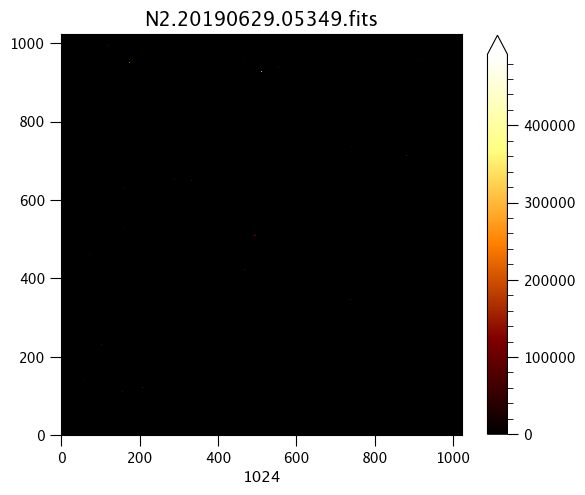

12.0
12.0
12.1
12.2
12.2
12.1
12.2
12.1
KOA Guide Star Magnitude = 12.1
NOTE: Results for MAOS configuration files marked with ***

20190629.dimm.dat saved to /Users/bdigia/myg3/datadnload_dir_nirc2_calib0_2019-06-29/lev0/
20190629.masspro.dat saved to /Users/bdigia/myg3/datadnload_dir_nirc2_calib0_2019-06-29/lev0/
cfht-wx.2019.dat saved to /Users/bdigia/myg3/datadnload_dir_nirc2_calib0_2019-06-29/lev0/
phto.20190629.dat saved to /Users/bdigia/myg3/datadnload_dir_nirc2_calib0_2019-06-29/lev0/

Date of observation is  2019-06-29 (UT)
Exposure time is	01:29:09.940 to 01:29:24.478 (UT)

Could not locate DIMM data close to  1.4858333333333333
Could not locate MASS data close to  1.4858333333333333
Could not locate DIMM data close to  1.49
Could not locate MASS data close to  1.49
Closest DIMM data to beginning of exposure:	0.6600	at 2019:6:29:6:8:49
Closest DIMM data to end of exposure:		0.6600	at 2019:6:29:6:8:49
Average DIMM over exposure:			0.6600

Closest MASS data to beginning of expo

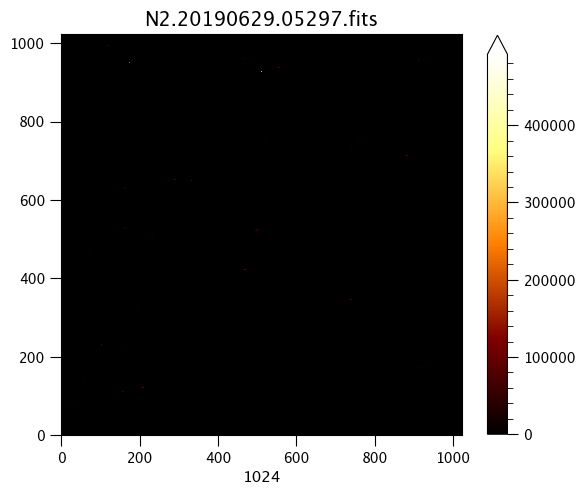

12.0
12.0
12.1
12.2
12.2
12.1
12.2
12.1
KOA Guide Star Magnitude = 12.1
NOTE: Results for MAOS configuration files marked with ***

20190629.dimm.dat exists in directory /Users/bdigia/myg3/datadnload_dir_nirc2_calib0_2019-06-29/lev0/, not downloading.
20190629.masspro.dat exists in directory /Users/bdigia/myg3/datadnload_dir_nirc2_calib0_2019-06-29/lev0/, not downloading.
cfht-wx.2019.dat exists in directory /Users/bdigia/myg3/datadnload_dir_nirc2_calib0_2019-06-29/lev0/, not downloading.
phto.20190629.dat exists in directory /Users/bdigia/myg3/datadnload_dir_nirc2_calib0_2019-06-29/lev0/, not downloading.

Date of observation is  2019-06-29 (UT)
Exposure time is	01:28:17.985 to 01:28:32.523 (UT)

Could not locate DIMM data close to  1.471388888888889
Could not locate MASS data close to  1.471388888888889
Could not locate DIMM data close to  1.4755555555555557
Could not locate MASS data close to  1.4755555555555557
Closest DIMM data to beginning of exposure:	0.6600	at 2019:6:29:6:8:49


In [5]:
# Simulation seeds
seeds = np.array([1, 1000, 5000, 10000])
# Simulation types/modes
simtypes = ['piston', 'psd+ncpa-unseen', 'psd+ncpa-seen']
baseroot = Path("/Users/bdigia/work/ao/keck/maos/keck/my_base/")
starpath = Path("/Users/bdigia/code/python/paarti/paarti/utils/master_tycho_list_v12.txt")
# Run simulation for each KOA image in koa_file array
for koa in koa_files:
    print(koa)
    with fits.open(koa) as koa_fits:
        hdu = koa_fits[0]
        hdr = hdu.header

        # Zenith angle
        angle = np.degrees(np.arccos(1.0/float(hdr['AIRMASS'])))
        # Calculate atm parameters
        koa_path = Path(koa)
        magnitude = ku.lookup_koa_object(koa_path, starpath)
        print(f"KOA Guide Star Magnitude = {magnitude}")
        thetax = [0.0, 0.0, 0.0] # arcsec, on-axis
        thetay = [0.0, 0.0, 0.0] # arcsec, on-axis
        fried, turbpro, windspds, winddrcts, _, _, _, _, _, _ = mu.estimate_on_sky_conditions(koa, 
                                                                                              koa_path.parent.as_posix() + "/", 
                                                                                              verbose=True)

        # Wavelength at which to run MAOS (microns)
        wvl = float(hdr['TARGWAVE']) * 1.0e-6 # multiply by 1e-6 to convert from microns to m
        # STRAP WFS integration time (milli-sec)
        if 'STINTTIM' not in hdr:
            continue
        hdr_strap_int_time = float(hdr['STINTTIM'])
        # SHWFS frame rate (Hz)
        hdr_shwfs_frame_rate = float(hdr['WSFRRT'])
        hdr_strap_frame_rate = (1.0/hdr_strap_int_time)*1000.0

        # Set sim_dt to fastest WFS readout rate in Hz
        if hdr_shwfs_frame_rate > hdr_strap_frame_rate:
            max_frame_rate = hdr_shwfs_frame_rate
            print(f"SHWFS frame rate is maximum = {max_frame_rate} Hz >= {hdr_strap_frame_rate}")
        else:
            max_frame_rate = hdr_strap_frame_rate
            print(f"STRAP frame rate is maximum = {max_frame_rate} Hz >= {hdr_shwfs_frame_rate}")

        sim_dt = 1.0/max_frame_rate
        hdr_shwfs_int_time = (1.0/hdr_shwfs_frame_rate)*1000.0 # ms
        # sim_dt = (1.0/472.0)*1000.0 # ms

        howfs_dtrat = (sim_dt / hdr_shwfs_int_time)*1000.0
        strap_dtrat = (sim_dt / hdr_strap_int_time)*1000.0
        # Compose powfs.dtrat array for input into MAOS config command override
        if howfs_dtrat < 1:
            howfs_dtrat = 1
        elif strap_dtrat < 1:
            strap_dtrat = 1
        dtrat = [int(howfs_dtrat), int(strap_dtrat), 7080]
        
        # Calculate siglev/bkgrnd/nearecon config parameters using variable
        # integration times from headers and mag of KOA guide star (KOA engcalib
        # images have LGS == NGS)
        _, howfs_nearecon, howfs_siglev, howfs_bkgrnd = mu.keck_nea_photons(magnitude, 'LGSWFS', 
                                                                            hdr_shwfs_int_time/1000.0) # convert to sec
        _, strap_nearecon, strap_siglev, strap_bkgrnd = mu.keck_nea_photons(magnitude, 'STRAP', 
                                                                            hdr_strap_int_time/1000.0) # convert to sec
        nearecon = [howfs_nearecon, strap_nearecon, 8.4]
        siglev = [howfs_siglev, strap_siglev, 3723]
        bkgrnd = [howfs_bkgrnd, strap_bkgrnd, 25.3]

        for seed in seeds:
            for mode in simtypes:
                if mode == 'piston':
                    surf_cmd = ["Keck_ncpa_rmswfe130nm.fits"]
                    # Fetch name of current input PSD FITS file in MAOS config file keck_sim.conf
                    psd_file = ''
                elif mode == 'psd+ncpa-seen':
                    mode = 'surf_wfs1'
                    surf_cmd = ["Keck_ncpa_rmswfe130nm.fits", "'r0=0.36;l0=3.39;ht=40000;slope=-2; SURFWFS=1; SURFEVL=1; seed=10;'"]
                    psd_file = "PSD_Keck_ws26.47mas_vib26mas_rad2.fits"
                elif mode == 'psd+ncpa-unseen':
                    mode = 'surf_wfs0'
                    surf_cmd = ["Keck_ncpa_rmswfe130nm.fits", "'r0=0.36;l0=3.39;ht=40000;slope=-2; SURFWFS=0; SURFEVL=1; seed=10;'"]
                    psd_file = "PSD_Keck_ws26.47mas_vib26mas_rad2.fits"
                else:
                    raise ValueError(f"Invalid MAOS simulation type '{type}'. Valid types are currently: 'piston', 'psd+ncpa-seen', 'psd+ncpa-unseen'. See help() for further info")
        
                # Must be in MAOS simulation directory to run successfully
                if os.getcwd() != baseroot.as_posix():
                    os.chdir(baseroot)

                maos_cmd = f"maos -o A_keck_scao_lgs_koa_{mode}_comp_{koa[60:65]}_seed{seed}_epoch{koa[51:59]} -c A_keck_scao_lgs.conf sim.seeds={seed} evl.wvl={wvl} sim.dt={sim_dt} sim.dtref={sim_dt} powfs.dtrat={dtrat} sim.zadeg={angle} powfs.siglev={siglev} powfs.bkgrnd={bkgrnd} powfs.nearecon={nearecon} sim.zadeg={angle} sim.wspsd={psd_file} atm.r0z={fried.value} atm.wt={turbpro} atm.ws={windspds} atm.wddeg={winddrcts} surf={surf_cmd} -O"
                # os.system(maos_cmd)